<a href="https://colab.research.google.com/github/l21140890-cyber/Analisis-y-visualizacion-de-datos/blob/main/Toma_de_decisiones_basadas_en_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Práctica 1 — Flujo de análisis en R**

Rows: 4
Columns: 3
$ fecha <chr> "01/01/2026", "02/01/2026", "03/01/2026", "04/01/2026"
$ monto <dbl> 1200, 1500, 1800, 2000
$ zona  <chr> "norte", "sur", "norte", "sur"


       fecha        monto             zona  
 Length   : 4   Min.   :1200   Length   :4  
 N.unique : 4   1st Qu.:1425   N.unique :2  
 N.blank  : 0   Median :1650   N.blank  :0  
 Min.nchar:10   Mean   :1625   Min.nchar:3  
 Max.nchar:10   3rd Qu.:1850   Max.nchar:5  
                Max.   :2000                

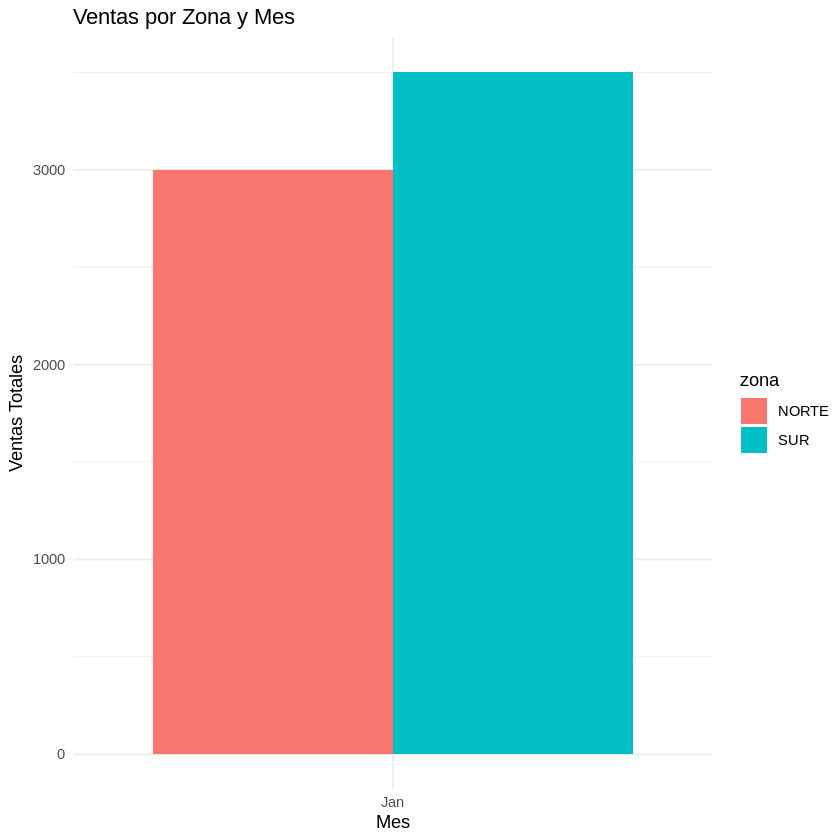

In [3]:
library(tidyverse)
library(lubridate)

# Crear datos de ejemplo
datos <- data.frame(
  fecha = c("01/01/2026","02/01/2026","03/01/2026","04/01/2026"),
  monto = c(1200, 1500, 1800, 2000),
  zona = c("norte","sur","norte","sur")
)

# Explorar estructura
glimpse(datos)
summary(datos)

# Limpiar datos
datos_limpios <- datos |>
  drop_na(monto) |>
  mutate(
    fecha = dmy(fecha),
    mes = month(fecha, label = TRUE),
    zona = str_to_upper(zona)
  )

# KPIs
resumen <- datos_limpios |>
  group_by(zona, mes) |>
  summarise(
    total = sum(monto),
    tickets = n(),
    ticket_prom = mean(monto),
    .groups = "drop"
  )

# Visualización
ggplot(resumen, aes(x = mes, y = total, fill = zona)) +
  geom_col(position = "dodge") +
  labs(
    title = "Ventas por Zona y Mes",
    x = "Mes",
    y = "Ventas Totales"
  ) +
  theme_minimal()

**Práctica 2 — Simulación Monte Carlo en R**

Utilidad promedio: 179054.3 


2.5%      97.5% 
 -7495.676 370233.786

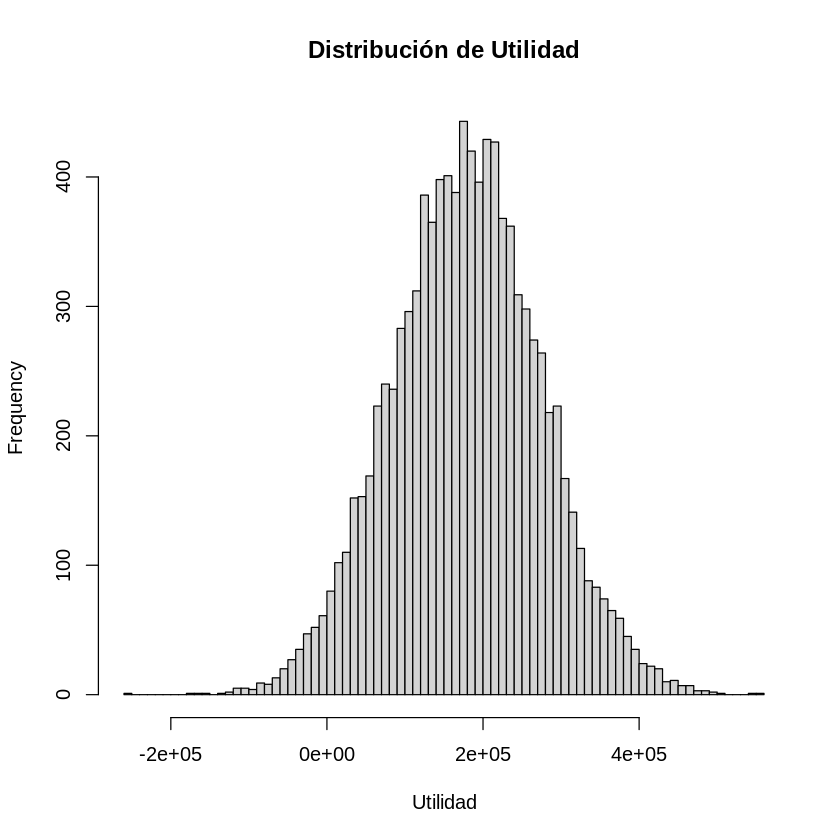

In [4]:
set.seed(42)

n_sim <- 10000

ingresos <- rnorm(n_sim, mean = 500000, sd = 80000)
costos <- rnorm(n_sim, mean = 320000, sd = 50000)

utilidad <- ingresos - costos

cat("Utilidad promedio:", mean(utilidad), "\n")

quantile(utilidad, c(0.025, 0.975))

hist(
  utilidad,
  breaks = 60,
  main = "Distribución de Utilidad",
  xlab = "Utilidad"
)